UTS BIG DATA - MANIPULASI DATA & VISUALISASI <br>

NAMA : Bifaqih Zulfa<br>
NIM : 12231945<br>
PRODI : Informatika<br>


SOAL A: Data Profiling & Preprocessing

1. Penggabungan Dataset dan Mengetahui Jumlah Baris

In [13]:
import pandas as pd

# 1. Membaca dataset langsung dari URL raw GitHub
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

# 2. Menggabungkan kedua dataset secara vertikal
df_gabungan = pd.concat([df_yk, df_mgl], ignore_index=True)

# 3. Mengetahui jumlah seluruh baris dan kolom data
print(f"Jumlah baris dan kolom setelah digabung: {df_gabungan.shape}")
print(f"Total seluruh baris data: {len(df_gabungan)} baris")

Jumlah baris dan kolom setelah digabung: (23849, 6)
Total seluruh baris data: 23849 baris


2. Proses Removing Outliers pada Kolom Harga

In [14]:
# Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
Q1 = df_gabungan['harga'].quantile(0.25)
Q3 = df_gabungan['harga'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Memfilter data untuk membuang outliers
df_clean_outlier = df_gabungan[(df_gabungan['harga'] >= batas_bawah) & (df_gabungan['harga'] <= batas_atas)]

print(f"Jumlah baris sebelum cleaning outlier: {len(df_gabungan)}")
print(f"Jumlah baris setelah cleaning outlier: {len(df_clean_outlier)}")

Jumlah baris sebelum cleaning outlier: 23849
Jumlah baris setelah cleaning outlier: 21349


3. Checking Missing Value dan Menghitung Jumlahnya

In [15]:
# Mengecek jumlah missing value per kolom
missing_data = df_clean_outlier.isnull().sum()
print("Jumlah Missing Value per Kolom:")
print(missing_data)

# Total seluruh missing value di dataset
total_missing = df_clean_outlier.isnull().sum().sum()
print(f"\nTotal seluruh data missing value: {total_missing}")

Jumlah Missing Value per Kolom:
tanggal    4
kode       5
nama       4
jumlah     5
harga      0
area       0
dtype: int64

Total seluruh data missing value: 18


4. Checking Duplikasi dan Melakukan Deduplikasi

In [16]:
# Mengecek jumlah data duplikat
jumlah_duplikat = df_clean_outlier.duplicated().sum()
print(f"Jumlah data duplikat ditemukan: {jumlah_duplikat}")

# Melakukan deduplikasi (menghapus data duplikat)
df_final = df_clean_outlier.drop_duplicates()
print(f"Jumlah baris akhir setelah deduplikasi: {len(df_final)}")

Jumlah data duplikat ditemukan: 6842
Jumlah baris akhir setelah deduplikasi: 14507


SOAL B: Visualisasi Data (Line Chart "Telur Ayam Negeri")

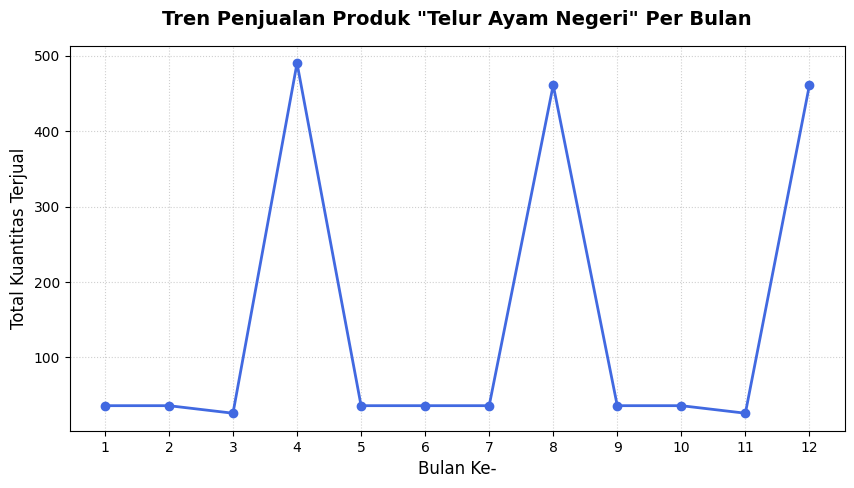

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PROSES ULANG DATA SESUAI SOAL A (Amankan dari Missing Value) ---
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)
df_gabungan = pd.concat([df_yk, df_mgl], ignore_index=True)

# Bersihkan Baris yang Kolom 'nama' atau 'tanggal'-nya Kosong (Drop Missing Values)
df_clean = df_gabungan.dropna(subset=['nama', 'tanggal', 'jumlah']).copy()

# --- 2. PENANGANAN TANGGAL & EKSTRAK BULAN ---
# Menggunakan parameter errors='coerce' dan format='mixed' agar semua format aman
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'], errors='coerce', format='mixed', dayfirst=True)

# Buang data yang tanggalnya gagal terkonversi (jika ada)
df_clean = df_clean.dropna(subset=['tanggal'])

# Ekstrak bulan menjadi angka (1-12)
df_clean['bulan'] = df_clean['tanggal'].dt.month

# --- 3. FILTER DAN AGREGASI PRODUK ---
# Filter berdasarkan nama produk yang dicari
df_telur = df_clean[df_clean['nama'].str.contains('Telur Ayam Negeri', case=False, na=False)]

# Hitung total jumlah yang terjual per bulan
tren_penjualan = df_telur.groupby('bulan')['jumlah'].sum().reset_index()

# Sempurnakan urutan indeks bulan dari 1 sampai 12 (isi angka 0 jika ada bulan yang kosong)
tren_penjualan = tren_penjualan.set_index('bulan').reindex(range(1, 13), fill_value=0).reset_index()

# --- 4. VISUALISASI LINE CHART ---
plt.figure(figsize=(10, 5))
plt.plot(tren_penjualan['bulan'], tren_penjualan['jumlah'], marker='o', color='royalblue', linestyle='-', linewidth=2)

# Atur Judul dan Sumbu Grafik
plt.title('Tren Penjualan Produk "Telur Ayam Negeri" Per Bulan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan Ke-', fontsize=12)
plt.ylabel('Total Kuantitas Terjual', fontsize=12)
plt.xticks(range(1, 13)) # Memastikan sumbu X memuat angka 1 sampai 12
plt.grid(True, linestyle=':', alpha=0.6)

# Tampilkan Grafik
plt.show()